In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [9]:
df["TotalCharges"].sample(10)

4178    3948.45
35       7251.7
992       555.4
683      4188.4
3276     317.25
6545     703.55
3675       20.5
853      352.65
759      6563.4
5309     1278.8
Name: TotalCharges, dtype: object

In [10]:
(df == "").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*50)

customerID
7043
--------------------------------------------------
gender
2
--------------------------------------------------
SeniorCitizen
2
--------------------------------------------------
Partner
2
--------------------------------------------------
Dependents
2
--------------------------------------------------
tenure
73
--------------------------------------------------
PhoneService
2
--------------------------------------------------
MultipleLines
3
--------------------------------------------------
InternetService
3
--------------------------------------------------
OnlineSecurity
3
--------------------------------------------------
OnlineBackup
3
--------------------------------------------------
DeviceProtection
3
--------------------------------------------------
TechSupport
3
--------------------------------------------------
StreamingTV
3
--------------------------------------------------
StreamingMovies
3
--------------------------------------------------
Contract
3
----

In [12]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

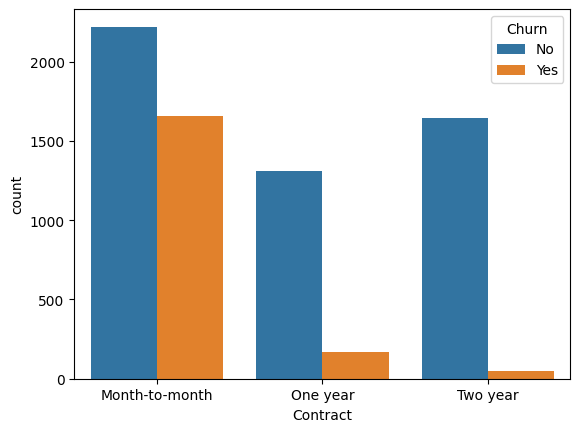

In [15]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)
plt.show()

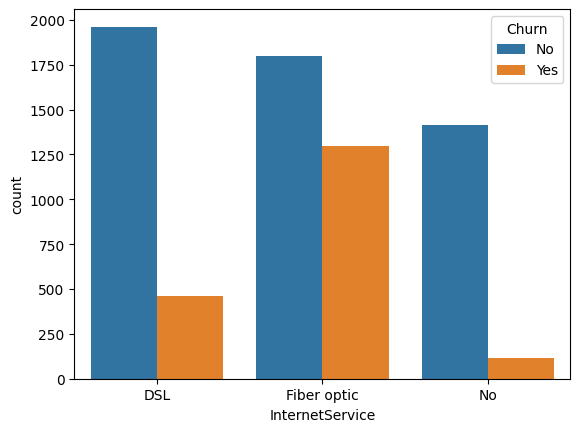

In [16]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)
plt.show()

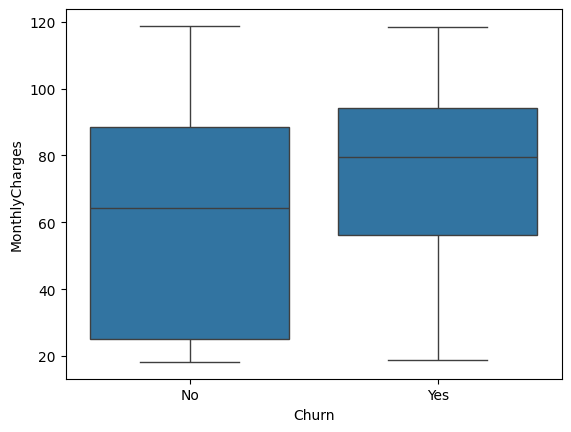

In [17]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.show()

In [18]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [20]:
df["TotalCharges"].dtype

dtype('O')

In [21]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [22]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].dtype

dtype('float64')

In [23]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [24]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [25]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [26]:
df["RevenueScore"] = (
    df["MonthlyCharges"] * df["tenure"]
)

df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

In [27]:
df["TotalCharges"].dtype

dtype('float64')

In [28]:
df[[
    "tenure",
    "MonthlyCharges",
    "RevenueScore",
    "AvgMonthlySpend"
]].head()

,tenure,MonthlyCharges,RevenueScore,AvgMonthlySpend
0,1,29.85,29.85,14.925000
1,34,56.95,1936.30,53.985714
2,2,53.85,107.70,36.050000
3,45,42.30,1903.50,40.016304
4,2,70.70,141.40,50.550000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df = df.drop(columns=["customerID"])

In [31]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [32]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [39]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1,12,24,48,72],
    labels=[
        "New",
        "Growing",
        "Established",
        "Loyal"
    ]
)

In [40]:
df["TenureGroup"].value_counts()

TenureGroup
Loyal          2239
New            2186
Established    1594
Growing        1024
Name: count, dtype: int64

In [41]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [42]:
categorical_cols = X.select_dtypes(
    include=["object","category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(categorical_cols)
print(numerical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'RevenueScore', 'AvgMonthlySpend']


In [43]:
df.to_csv(
    "../data/processed_telco.csv",
    index=False
)

In [44]:
pd.read_csv(
    "../data/processed_telco.csv"
).head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,RevenueScore,AvgMonthlySpend,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.85,14.925000,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,1936.30,53.985714,Established
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,107.70,36.050000,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1903.50,40.016304,Established
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,141.40,50.550000,New
